In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [4]:
#Charger les données
X_train = pd.read_csv("../data/X_train.csv")
X_test = pd.read_csv("../data/X_test.csv")
y_train = pd.read_csv("../data/y_train.csv")
y_test = pd.read_csv("../data/y_test.csv")

y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

In [5]:
#Logistic Regression model (pour problème de classification)
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)
logistic_proba = logistic_model.predict_proba(X_test)[:, 1]

In [7]:
#Nouveau Model: Random Forest (ensemble d'arbre de décision=> chaque arbre donne une prédiction)
random_forest_model = RandomForestClassifier(
    n_estimators=100, #Le modèle utilise 100 arbres.
    random_state=42,  #Permet d’obtenir les mêmes résultats à chaque exécution.
    class_weight="balanced" #Très important pour notre dataset déséquilibré. Cela donne plus d’importance à la classe minoritaire
)

random_forest_model.fit(X_train, y_train)

rf_pred = random_forest_model.predict(X_test)
rf_proba = random_forest_model.predict_proba(X_test)[:, 1]

In [8]:
# Fonction d'évaluation
def evaluate_model(name, y_test, y_pred, y_proba):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_proba)
    }

In [9]:
#Comparaison des modèles
results = []

results.append(
    evaluate_model("Logistic Regression", y_test, logistic_pred, logistic_proba)
)

results.append(
    evaluate_model("Random Forest", y_test, rf_pred, rf_proba)
)

comparison_df = pd.DataFrame(results)

comparison_df

,Model,Accuracy,Precision,Recall,F1-score,ROC AUC
0,Logistic Regression,0.800995,0.642424,0.566845,0.602273,0.836462
1,Random Forest,0.768301,0.553097,0.668449,0.605327,0.820176


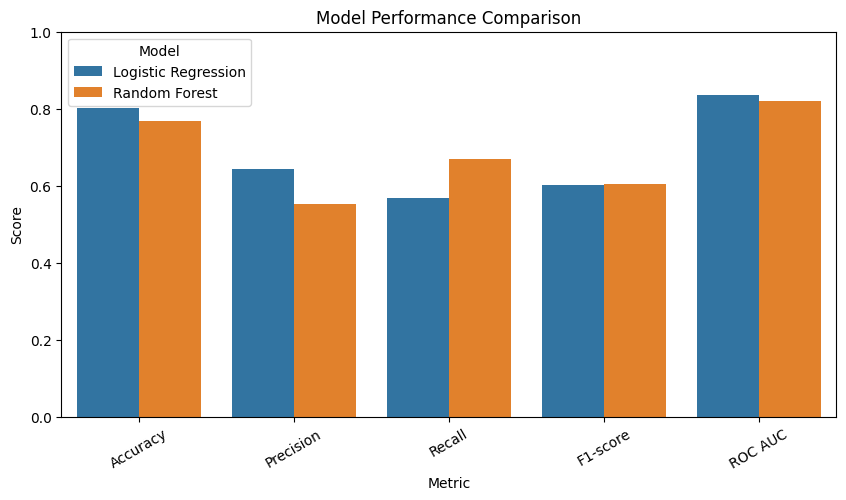

In [11]:
#Visualiser la comparaison
comparison_melted = comparison_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_melted, x="Metric", y="Score", hue="Model")
plt.title("Model Performance Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.show()

In [ ]:
#Importance des variables
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
3,TotalCharges,0.171313
1,tenure,0.167531
2,MonthlyCharges,0.154535
25,Contract_Two year,0.061437
10,InternetService_Fiber optic,0.040453
28,PaymentMethod_Electronic check,0.036361
24,Contract_One year,0.032076
13,OnlineSecurity_Yes,0.031198
4,gender_Male,0.025567
19,TechSupport_Yes,0.023545


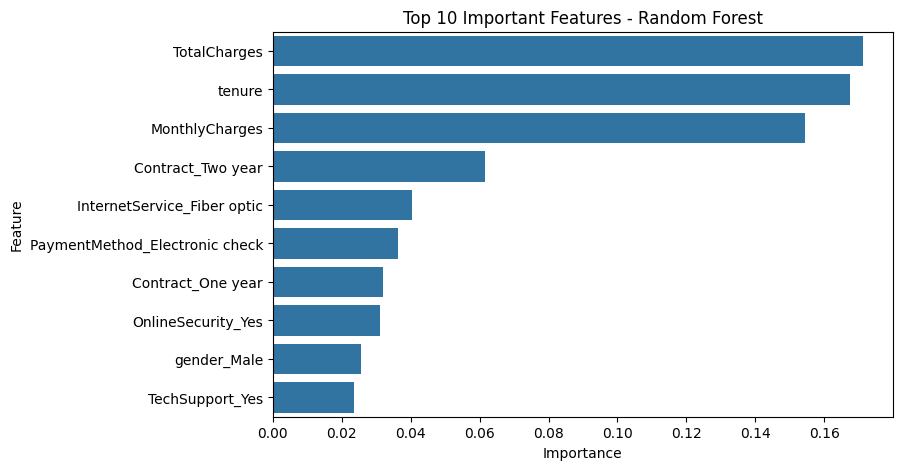

In [13]:
#Visualiser les variables les plus importantes
top_features = feature_importance.head(10)

plt.figure(figsize=(8, 5))
sns.barplot(data=top_features, x="Importance", y="Feature")
plt.title("Top 10 Important Features - Random Forest")
plt.show()

In [14]:
#Sauvegarder modèle final
joblib.dump(random_forest_model, "../models/final_model.pkl")

['../models/final_model.pkl']

Random Forest was selected as the final model because it achieved a higher recall than Logistic Regression. In customer churn prediction, recall is especially important because the business objective is to identify as many at-risk customers as possible before they leave.